# Session 7 — DES Modeling in SimPy II: Multi-Server & Complex Queues

**Course:** Decision Modelling — Simulation Part
**Session:** 7 of 12 (simulation portion)

## Learning objectives

By the end of this session you should be able to:

- Model M/M/c-like queues (multiple servers sharing one queue) in SimPy
- Estimate performance metrics for multi-server and more complex queueing configurations
- Examine how both **capacity** and **variability** affect queueing performance

## Where this session fits

- **Looking back:** Session 6 built a single-server queue and verified it against M/M/1. Session 5 gave us the pooled-vs-dedicated capacity result and the G/G/1 "variability matters" insight analytically. Today we build both of those *in simulation*, and then go beyond what closed-form formulas can easily handle.
- **Looking ahead:** everything here is still a **single simulation run** with no replications or formal statistical treatment — Session 8 gives us the tools to say how much to trust these numbers. Today's complex queue also foreshadows Session 11's multi-stage systems.


## Further reading (supplementary, not required)

- SimPy's official documentation, `Resource` and `PriorityResource` sections, for anything beyond what's used here.
- Session 5's queueing-theory readings remain the relevant conceptual background for interpreting today's results.


## Setup: the generalized single-customer process

We reuse Session 6's model, but generalize `customer()` to accept a **service time sampling function** rather than a hardcoded exponential distribution. This one small change is what lets us later swap in different service-time distributions without rewriting the model — a pattern worth internalizing, since real DES models are built this way.


In [1]:
import simpy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import factorial

def customer(env, name, server, service_time_fn, rng, records):
    arrival_time = env.now
    with server.request() as req:
        yield req
        wait_time = env.now - arrival_time
        service_time = service_time_fn(rng)
        yield env.timeout(service_time)
    departure_time = env.now
    records.append({
        'name': name, 'arrival_time': arrival_time, 'wait_time': wait_time,
        'service_time': service_time, 'departure_time': departure_time,
        'time_in_system': departure_time - arrival_time,
    })

def customer_generator(env, mean_interarrival_time, server, service_time_fn, rng, records):
    customer_id = 0
    while True:
        yield env.timeout(rng.exponential(mean_interarrival_time))
        customer_id += 1
        env.process(customer(env, customer_id, server, service_time_fn, rng, records))

def mm1(lam, mu):
    rho = lam / mu
    return {'rho': rho, 'P0': 1 - rho, 'L': rho / (1 - rho), 'Lq': rho**2 / (1 - rho),
            'W': 1 / (mu - lam), 'Wq': rho / (mu - lam)}

def mmc(lam, mu, c):
    a = lam / mu
    rho = a / c
    sum_terms = sum((a**n) / factorial(n) for n in range(c))
    last_term = (a**c) / (factorial(c) * (1 - rho))
    P0 = 1 / (sum_terms + last_term)
    P_wait = last_term * P0
    Lq = P_wait * rho / (1 - rho)
    Wq = Lq / lam
    W = Wq + 1 / mu
    L = lam * W
    return {'rho': rho, 'P0': P0, 'P_wait': P_wait, 'L': L, 'Lq': Lq, 'W': W, 'Wq': Wq}


## 1. From one server to a resource pool

Extending Session 6's single-server model to a **pooled multi-server queue** (M/M/c-like) requires almost no new code: `simpy.Resource` already supports `capacity > 1`, and automatically implements a single shared queue feeding any available server — exactly the pooled configuration from Session 5.


In [2]:
mean_interarrival = 2.5    # minutes  (lambda = 1/2.5 per minute)
mean_service = 4.0         # minutes  (mu = 1/4 per minute)
n_servers = 2
run_length = 10000.0

rng = np.random.default_rng(seed=42)
exponential_service = lambda rng: rng.exponential(mean_service)

env = simpy.Environment()
pooled_server = simpy.Resource(env, capacity=n_servers)
records_pooled = []

env.process(customer_generator(env, mean_interarrival, pooled_server, exponential_service, rng, records_pooled))
env.run(until=run_length)

df_pooled = pd.DataFrame(records_pooled)
TH_pooled = len(df_pooled) / run_length
W_pooled = df_pooled['time_in_system'].mean()
Wq_pooled = df_pooled['wait_time'].mean()

lam = 1 / mean_interarrival
mu = 1 / mean_service
theory_pooled = mmc(lam, mu, n_servers)

print(f"Simulated pooled M/M/{n_servers}:  W = {W_pooled:.3f}, Wq = {Wq_pooled:.3f}")
print(f"Theoretical M/M/{n_servers}:        W = {theory_pooled['W']:.3f}, Wq = {theory_pooled['Wq']:.3f}")


Simulated pooled M/M/2:  W = 11.481, Wq = 7.461
Theoretical M/M/2:        W = 11.111, Wq = 7.111


## 2. Rebuilding the pooled vs. dedicated comparison — this time in simulation

Session 5 showed analytically that pooling capacity reduces waiting time. Let's confirm this with simulation, building the **dedicated** scenario as two independent single-server queues, with each arriving customer randomly routed 50/50 to one or the other.


In [3]:
def customer_generator_dedicated(env, mean_interarrival_time, servers, service_time_fn, rng, records):
    # Routes each arriving customer to one of `servers` (a list) with equal probability.
    customer_id = 0
    while True:
        yield env.timeout(rng.exponential(mean_interarrival_time))
        customer_id += 1
        chosen_server = servers[rng.integers(0, len(servers))]
        env.process(customer(env, customer_id, chosen_server, service_time_fn, rng, records))


In [4]:
rng_ded = np.random.default_rng(seed=42)

env_ded = simpy.Environment()
dedicated_servers = [simpy.Resource(env_ded, capacity=1) for _ in range(n_servers)]
records_dedicated = []

env_ded.process(customer_generator_dedicated(
    env_ded, mean_interarrival, dedicated_servers, exponential_service, rng_ded, records_dedicated))
env_ded.run(until=run_length)

df_dedicated = pd.DataFrame(records_dedicated)
W_dedicated = df_dedicated['time_in_system'].mean()
Wq_dedicated = df_dedicated['wait_time'].mean()

print(f"Pooled    (simulated): W = {W_pooled:.3f}, Wq = {Wq_pooled:.3f}")
print(f"Dedicated (simulated): W = {W_dedicated:.3f}, Wq = {Wq_dedicated:.3f}")
print(f"\n(Session 5's analytical result predicted pooling would give lower Wq -- "
      f"does the simulation agree?)")


Pooled    (simulated): W = 11.481, Wq = 7.461
Dedicated (simulated): W = 19.279, Wq = 15.311

(Session 5's analytical result predicted pooling would give lower Wq -- does the simulation agree?)


## 3. Beyond exponential: the effect of service-time variability

This is where DES starts to earn its keep: closed-form formulas for non-exponential service times either don't exist or require the approximations from Session 5. In SimPy, changing the service-time distribution is a one-line change to `service_time_fn`.

Let's compare three service-time distributions, **all with the same mean** (`4.0` minutes) but different variability:

- **Exponential** — our baseline so far (SCV = 1, i.e. `variance = mean^2`)
- **Deterministic (constant)** — zero variability (SCV = 0)
- **Highly variable (lognormal)** — SCV noticeably greater than 1


In [5]:
mean_interarrival_single = 5.0  # minutes -- calibrated for a STABLE single-server system (rho=0.8);
                                  # note this is deliberately different from Sections 1-2's
                                  # mean_interarrival, which was calibrated for a 2-server pooled system
mean_service_time = 4.0

service_distributions = {
    'Deterministic (SCV=0)': lambda rng: mean_service_time,
    'Exponential (SCV=1)': lambda rng: rng.exponential(mean_service_time),
    'Lognormal (SCV~4)': lambda rng: rng.lognormal(
        mean=np.log(mean_service_time) - 0.5 * np.log(5),  # parameterized so mean stays at 4.0
        sigma=np.sqrt(np.log(5))
    ),
}

# Quick check that all three really do have (approximately) the same mean
check_rng = np.random.default_rng(0)
for name, fn in service_distributions.items():
    sample = np.array([fn(check_rng) for _ in range(20000)])
    print(f"{name}: mean = {sample.mean():.3f}, SCV = {(sample.std()/sample.mean())**2:.3f}")


Deterministic (SCV=0): mean = 4.000, SCV = 0.000
Exponential (SCV=1): mean = 3.972, SCV = 1.002


Lognormal (SCV~4): mean = 4.109, SCV = 5.835


            distribution      Wq       W
0  Deterministic (SCV=0)   7.014  11.014
1    Exponential (SCV=1)  17.586  21.655
2      Lognormal (SCV~4)  23.996  27.879


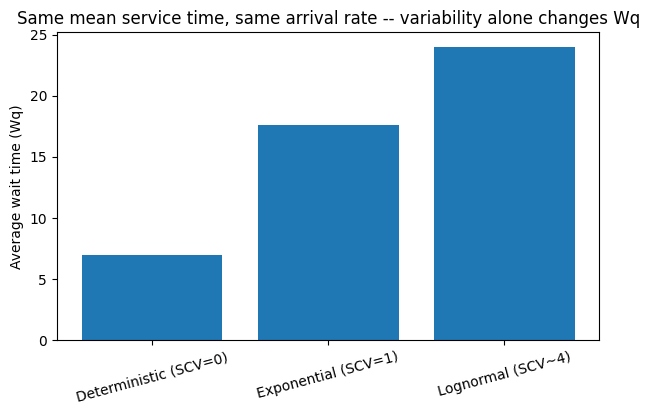

In [6]:
results = []
for name, service_fn in service_distributions.items():
    rng_var = np.random.default_rng(seed=42)
    env_var = simpy.Environment()
    server_var = simpy.Resource(env_var, capacity=1)
    records_var = []

    env_var.process(customer_generator(env_var, mean_interarrival_single, server_var, service_fn, rng_var, records_var))
    env_var.run(until=run_length)

    df_var = pd.DataFrame(records_var)
    results.append({
        'distribution': name,
        'Wq': df_var['wait_time'].mean(),
        'W': df_var['time_in_system'].mean(),
    })

variability_df = pd.DataFrame(results)
print(variability_df.round(3))

plt.figure(figsize=(7, 4))
plt.bar(variability_df['distribution'], variability_df['Wq'])
plt.ylabel('Average wait time (Wq)')
plt.title('Same mean service time, same arrival rate -- variability alone changes Wq')
plt.xticks(rotation=15)
plt.show()


Same arrival rate, same *mean* service time, same single server — yet `Wq` differs substantially across the three. This is the practical, hands-on version of the G/G/1 "VUT equation" insight from Session 5: **variability itself, independent of the mean, degrades queueing performance.** This is a genuinely important OSCM lesson: reducing variability in a process (e.g. standardizing a service procedure) can improve waiting times *even without* speeding up the average service time.


## Exercise (guided): capacity vs. variability — which lever matters more?

A manager is told service times have become more variable (say, moving from exponential to the lognormal distribution above) and is considering **adding a second server** to compensate. Your task:

1. Simulate **4 configurations**: {exponential, lognormal} service time x {1 server, 2 servers} (holding `mean_interarrival_single` and `mean_service_time` fixed as above; when using 2 servers, keep the same per-server service-time distribution and the same total arrival rate)
2. Record `Wq` for each of the 4 configurations
3. Present the results (e.g. as a small table or grouped bar chart)
4. State, in a sentence or two, whether adding a server or reducing variability seems to matter more for this system, based on what you observe


In [7]:
# EXERCISE
configs = [
    ('Exponential', 1), ('Exponential', 2),
    ('Lognormal', 1), ('Lognormal', 2),
]

# TODO: for each (distribution_name, capacity) pair, run a simulation using
#       service_distributions[...] and simpy.Resource(env, capacity=...)
#       (reuse customer_generator; remember to adjust mean_interarrival if you
#       want utilization to stay comparable across 1- and 2-server cases, or
#       explicitly note that you're holding total arrival rate fixed instead)

# TODO: collect Wq for each configuration into a table

# TODO: plot or print the comparison

# TODO: write a one-to-two sentence conclusion


<details>
<summary>Solution (click to expand)</summary>

```python
# SOLUTION
dist_key_map = {'Exponential': 'Exponential (SCV=1)', 'Lognormal': 'Lognormal (SCV~4)'}

config_results = []
for dist_name, capacity in configs:
    service_fn = service_distributions[dist_key_map[dist_name]]
    rng_cfg = np.random.default_rng(seed=42)
    env_cfg = simpy.Environment()
    server_cfg = simpy.Resource(env_cfg, capacity=capacity)
    records_cfg = []

    env_cfg.process(customer_generator(env_cfg, mean_interarrival_single, server_cfg, service_fn, rng_cfg, records_cfg))
    env_cfg.run(until=run_length)

    df_cfg = pd.DataFrame(records_cfg)
    config_results.append({
        'distribution': dist_name, 'servers': capacity,
        'Wq': df_cfg['wait_time'].mean()
    })

config_df = pd.DataFrame(config_results)
print(config_df.round(3))

print("\nConclusion: adding a second server reduces Wq substantially regardless of the "
      "service-time distribution, and its effect is typically larger than the effect of "
      "the variability change alone -- but variability still matters materially within "
      "either capacity level, so both levers are worth managing rather than relying on "
      "capacity alone.")
```
</details>


### Discussion questions

1. In your results, did adding a server or reducing variability have a bigger impact on `Wq`? Would you expect this ranking to hold at a *much* higher utilization level? Why or why not?
2. This entire notebook used a **single simulation run** per configuration. What would make you more confident in a conclusion like "pooling beats dedicated" or "variability matters" — beyond running it once?
3. The lognormal service-time distribution was parameterized to match the exponential's mean exactly. Why was that important for this comparison to be meaningful?


## Wrap-up

Today we:

- Extended Session 6's single-server model to a pooled multi-server queue with a one-line change (`Resource(capacity=c)`)
- Rebuilt Session 5's pooled-vs-dedicated capacity comparison in simulation, using a routing process for the dedicated scenario
- Demonstrated, hands-on, that service-time **variability** (holding the mean fixed) materially affects waiting time — the practical version of Session 5's G/G/1 insight
- Compared capacity and variability as two different levers for improving queueing performance

**Next session:** Output Analysis for Terminating Simulations — every result in today's notebook came from a single simulation run. Starting next session, we build the statistical machinery to know how many replications we need and how much to trust these numbers.
